In [1]:
import netCDF4 as nc
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
#import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.path as mpath
from scipy import stats

In [2]:
SALTdata=np.load("D:\\ihespdata\\2010-2023SALT_FSV.npy")
SALTdata2=np.load("D:\\ihespdata\\2024-2050SALT_FSV.npy")
SALTdata3=np.load("D:\\ihespdata\\2050-2100SALT_FSV.npy")
SALTdata12 = np.hstack((SALTdata,SALTdata2))
SALTdata123 = np.hstack((SALTdata12,SALTdata3))

ds222 =  nc.Dataset("D:\\ihespdata\\B.E.13.BHISTC5.ne120_t12.sehires38.003.sunway.pop.h.nday1.1916-02-01.nc")
sfluxfact = ds222['sflux_factor'][:]        # (msu*cm/s)/(kg SALT /m^2/s)
salinityfact = ds222['salinity_factor'][:]  # (msu*cm/s)/(kg FW /m^2/s)
SALTdata1234 = SALTdata123*sfluxfact/salinityfact        # (kg salt/m^2/s to kg freshwater/m^2/s); units remain unc

In [3]:
SFWFdata=np.load("D:\\ihespdata\\2010-2023areaSFWFSV.npy")
SFWFdata2=np.load("D:\\ihespdata\\2024-2050areaSFWFSV.npy")
SFWFdata3=np.load("D:\\ihespdata\\2050-2100areaSFWFSV.npy")

SFWFdata12 = np.hstack((SFWFdata,SFWFdata2))
SFWFdata123 = np.hstack((SFWFdata12,SFWFdata3))

In [4]:
MELTdata=np.load("D:\\ihespdata\\2010-2023MELT_FSV.npy")
MELTdata2=np.load("D:\\ihespdata\\2024-2050MELT_FSV.npy")
MELTdata3=np.load("D:\\ihespdata\\2050-2100MELT_FSV.npy")
MELTdata12 = np.hstack((MELTdata,MELTdata2))
MELTdata123 = np.hstack((MELTdata12,MELTdata3))

In [5]:
PRECdata=np.load("D:\\ihespdata\\2010-2023PREC_FSV.npy")
PRECdata2=np.load("D:\\ihespdata\\2024-2050PREC_FSV.npy")
PRECdata3=np.load("D:\\ihespdata\\2050-2100PREC_FSV.npy")
PRECdata12 = np.hstack((PRECdata,PRECdata2))
PRECdata123 = np.hstack((PRECdata12,PRECdata3))

In [6]:
ROFFdata=np.load("D:\\ihespdata\\2010-2023areaROFF_FSV.npy")
ROFFdata2=np.load("D:\\ihespdata\\2024-2050areaROFF_FSV.npy")
ROFFdata3=np.load("D:\\ihespdata\\2050-2100areaROFF_FSV.npy")
ROFFdata12 = np.hstack((ROFFdata,ROFFdata2))
ROFFdata123 = np.hstack((ROFFdata12,ROFFdata3))

In [7]:
EVAPdata=np.load("D:\\ihespdata\\2010-2023EVAP_FSV.npy")
EVAPdata2=np.load("D:\\ihespdata\\2024-2050EVAP_FSV.npy")
EVAPdata3=np.load("D:\\ihespdata\\2050-2100EVAP_FSV.npy")
EVAPdata12 = np.hstack((EVAPdata,EVAPdata2))
EVAPdata123 = np.hstack((EVAPdata12,EVAPdata3))

In [8]:
QFLUXdata=np.load("D:\\ihespdata\\2010-2023QFLUXSV.npy")
QFLUXdata2=np.load("D:\\ihespdata\\2024-2050QFLUXSV.npy")
QFLUXdata3=np.load("D:\\ihespdata\\2050-2100QFLUXSV.npy")
QFLUXdata12 = np.hstack((QFLUXdata,QFLUXdata2))
QFLUXdata123 = np.hstack((QFLUXdata12,QFLUXdata3))

ds222 =  nc.Dataset("D:\\ihespdata\\B.E.13.BHISTC5.ne120_t12.sehires38.003.sunway.pop.h.nday1.1916-02-01.nc")
latfus=ds222['latent_heat_fusion'][:]      # erg/g
latfus = latfus/1.e4
QFLUXdata1234 = QFLUXdata123/latfus

In [9]:
REST = SFWFdata123  - SALTdata1234 - MELTdata123 - PRECdata123  - EVAPdata123 

In [10]:
IOFF = SFWFdata123  - SALTdata1234 - MELTdata123 - PRECdata123  - EVAPdata123 - ROFFdata123

In [11]:
SFyear = SFWFdata123-QFLUXdata1234
AAASF = SFyear.reshape(89,12)
BBBSF = np.nanmean(AAASF,axis=1)
BBBSF = BBBSF/10000/1020/1000000

ICEyear = (MELTdata123+SALTdata1234)-QFLUXdata1234
AAAICE = ICEyear.reshape(89,12)
BBBICE = np.nanmean(AAAICE,axis=1)
BBBICE = BBBICE/10000/1020/1000000

ATMyear = (PRECdata123+EVAPdata123)
AAAATM = ATMyear.reshape(89,12)
BBBATM = np.nanmean(AAAATM,axis=1)
BBBATM = BBBATM/10000/1020/1000000


LANDyear = REST
AAAALAND = LANDyear.reshape(89,12)
BBBLAND = np.nanmean(AAAALAND,axis=1)
BBBLAND = BBBLAND/10000/1020/1000000

IOFFyear = IOFF
AAAAIOFF = IOFFyear.reshape(89,12)
BBBIOFF = np.nanmean(AAAAIOFF,axis=1)
BBBIOFF = BBBIOFF/10000/1020/1000000

ROFFyear = ROFFdata123
AAAAROFF = ROFFyear.reshape(89,12)
BBBROFF = np.nanmean(AAAAROFF,axis=1)
BBBROFF = BBBROFF/10000/1020/1000000

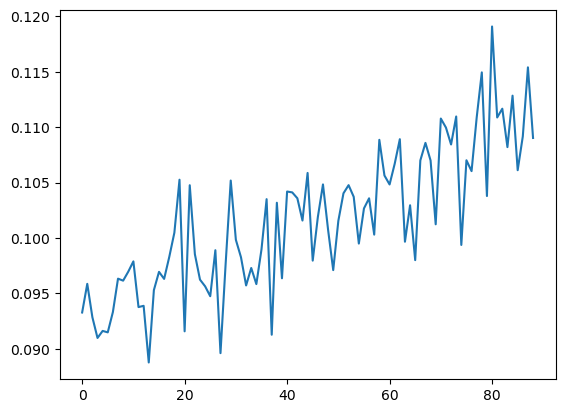

In [12]:
plt.plot(BBBLAND)


In [13]:
89*12

1068

In [14]:
CCC = np.arange(0,1068,12)


In [15]:
slope1,intercept1,r_value1,p_value1, std_err1 = stats.linregress(np.arange(0,89),BBBSF)
slope2,intercept2,r_value2,p_value2, std_err2 = stats.linregress(np.arange(0,89),BBBICE)
slope3,intercept3,r_value3,p_value3, std_err3 = stats.linregress(np.arange(0,89),BBBLAND)
slope4,intercept4,r_value4,p_value4, std_err4 = stats.linregress(np.arange(0,89),BBBATM)

slope5,intercept5,r_value5,p_value5, std_err5 = stats.linregress(np.arange(0,89),BBBIOFF)
slope6,intercept6,r_value6,p_value6, std_err6 = stats.linregress(np.arange(0,89),BBBROFF)

In [16]:
slope11,intercept11,r_value11,p_value11, std_err11 = stats.linregress(np.arange(0,25),BBBSF[:25])
slope22,intercept22,r_value22,p_value22, std_err22 = stats.linregress(np.arange(0,25),BBBICE[:25])
slope33,intercept33,r_value33,p_value33, std_err33 = stats.linregress(np.arange(0,25),BBBLAND[:25])
slope44,intercept44,r_value44,p_value44, std_err44 = stats.linregress(np.arange(0,25),BBBATM[:25])

slope55,intercept55,r_value55,p_value55, std_err55 = stats.linregress(np.arange(0,25),BBBIOFF[:25])
slope66,intercept66,r_value66,p_value66, std_err66 = stats.linregress(np.arange(0,25),BBBROFF[:25])

In [17]:
slope111,intercept111,r_value111,p_value111, std_err111 = stats.linregress(np.arange(0,50),BBBSF[:50])
slope222,intercept222,r_value222,p_value222, std_err222 = stats.linregress(np.arange(0,50),BBBICE[:50])
slope333,intercept333,r_value333,p_value333, std_err333 = stats.linregress(np.arange(0,50),BBBLAND[:50])
slope444,intercept444,r_value444,p_value444, std_err444 = stats.linregress(np.arange(0,50),BBBATM[:50])

slope555,intercept555,r_value555,p_value555, std_err555 = stats.linregress(np.arange(0,50),BBBIOFF[:50])
slope666,intercept666,r_value666,p_value666, std_err666 = stats.linregress(np.arange(0,50),BBBROFF[:50])

In [18]:
slope1111,intercept1111,r_value1111,p_value1111, std_err1111 = stats.linregress(np.arange(0,30),BBBSF[:30])
slope2222,intercept2222,r_value2222,p_value2222, std_err2222 = stats.linregress(np.arange(0,30),BBBICE[:30])
slope3333,intercept3333,r_value3333,p_value3333, std_err3333 = stats.linregress(np.arange(0,30),BBBLAND[:30])
slope4444,intercept4444,r_value4444,p_value4444, std_err4444 = stats.linregress(np.arange(0,30),BBBATM[:30])

slope5555,intercept5555,r_value5555,p_value5555, std_err5555 = stats.linregress(np.arange(0,30),BBBIOFF[:30])
slope6666,intercept6666,r_value6666,p_value6666, std_err6666 = stats.linregress(np.arange(0,30),BBBROFF[:30])

In [19]:
DDD = np.arange(0,1068)

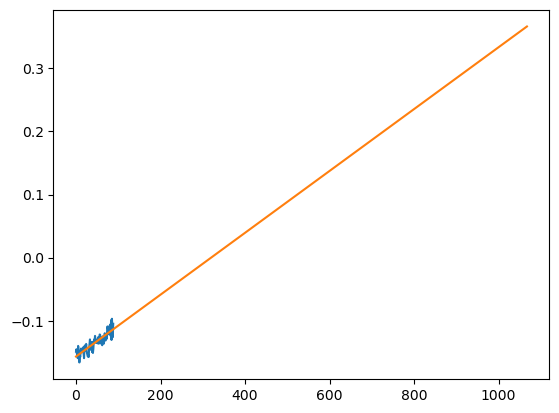

In [20]:
plt.plot(BBBICE)
plt.plot(slope2*DDD+intercept2)

In [21]:
slope1

0.0008528769180903161

In [22]:
slope11

0.0007523788697462512

In [23]:
slope111

0.0007023131923869441

In [24]:
slope1111

0.00042114167114197493

In [25]:
slope2

0.0004902943775839294

In [26]:
slope22

0.0003172417234193213

In [27]:
slope222

0.00040730555246716523

In [28]:
slope2222

7.069190309731933e-05

In [29]:
slope3

0.00020534915596387082

In [30]:
slope33

0.0002713621798006632

In [31]:
slope333

0.00018039215927589657

In [32]:
slope3333

0.00020780203903763336

In [33]:
slope4

0.0001572333845425162

In [34]:
slope44

0.00016377496652626594

In [35]:
slope444

0.00011461548064388193

In [36]:
slope4444

0.00014264772900702204

In [37]:
slope2+slope3+slope4

0.0008528769180903164

In [38]:
slope5

4.2398577626696375e-05

In [39]:
slope55

0.00016730410887300982

In [40]:
slope555

5.4712338766158735e-05

In [41]:
slope5555

9.529401323082839e-05

In [42]:
slope6

0.00016295057833717424

In [43]:
slope66

0.00010405807092765324

In [44]:
slope666

0.0001256798205097379

In [45]:
slope6666

0.0001125080258068051

In [46]:
DDD = np.arange(0,1068)

In [47]:
# Total surface freshwater flux
# Sea-ice brine rejection and melt on the Antarctic shelf

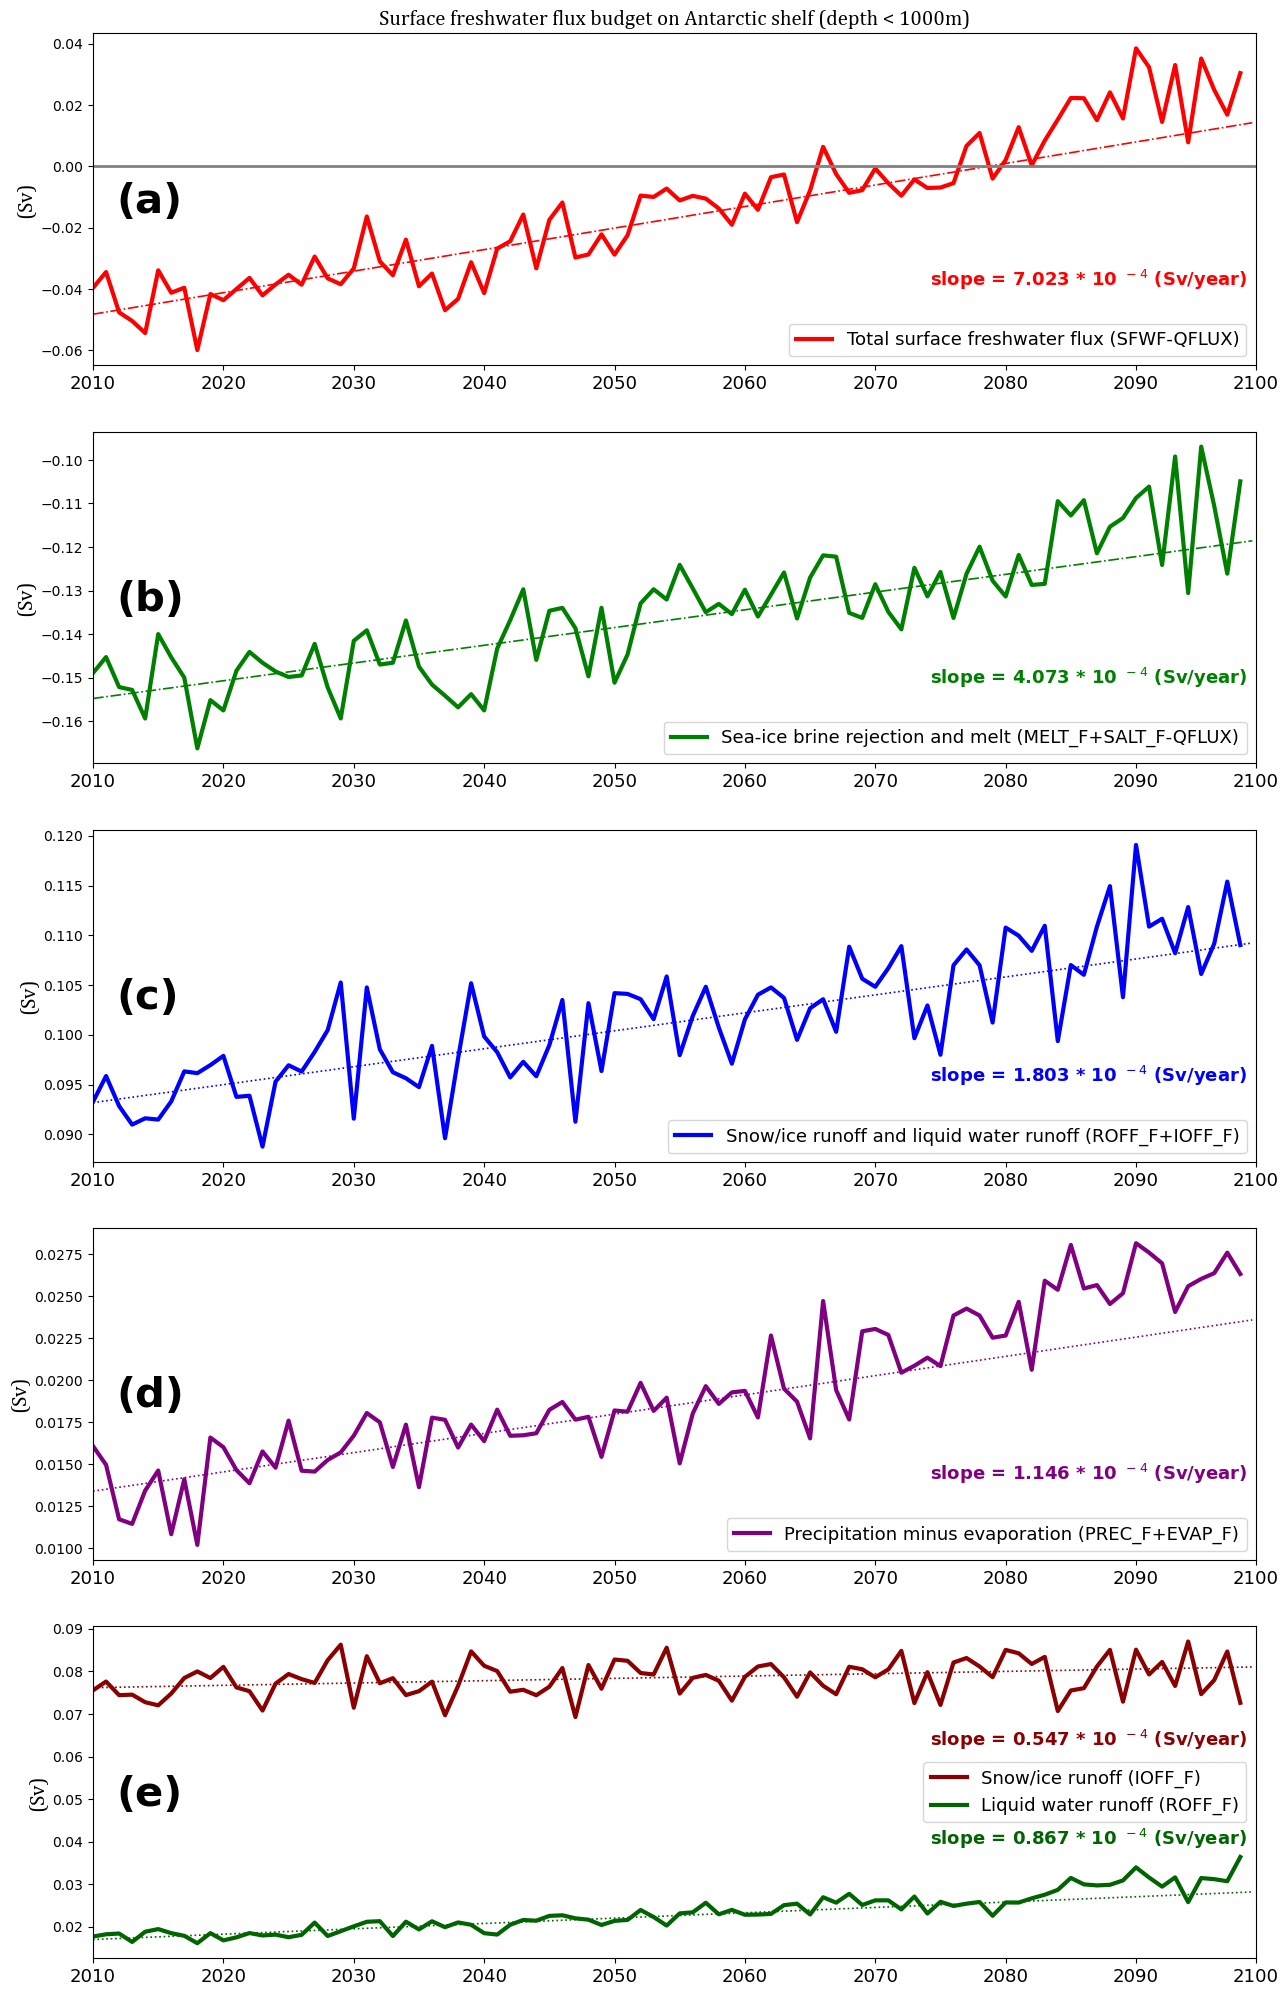

In [57]:
my_font = {'fontname':'Cambria', 'size':'15'}
fig = plt.figure(figsize=(15,25), dpi=100)
ax = plt.subplot(5, 1, 1)
#ax.plot(resultAASW_trans2,color = 'k',linestyle = '-', linewidth = 2, label = 'HR-PI')
#ax.plot(SFWFdata123*100000-QFLUXdata1234*100000,color = 'lightgrey',linestyle = '-', linewidth = 1)
ax.plot(CCC,BBBSF,color = 'red',linestyle = '-', linewidth = 3, label = 'Total surface freshwater flux (SFWF-QFLUX)')
#plt.plot(slope1*DDD/12+intercept1,color = 'red',linestyle = '--', linewidth = 1.2 )
#plt.plot(slope11*DDD[:300]/12+intercept11,color = 'red',linestyle = ':', linewidth = 1.2 )
plt.plot(slope111*DDD/12+intercept111,color = 'red',linestyle = '-.', linewidth = 1.2 )
#ax.set_ylim((-3.5,1.5))
ax.set_xlim((0,1070))
ax.plot([0,1100],[0,0],'grey',linewidth=2)
#ax.plot([0,1100],[-10,-10],'grey',linewidth=0.5)
ax.legend(fontsize = 13,loc='lower right') 
ax.set_ylabel('(Sv)', **my_font)
ax.set_xticks([0,120,240,360,480,600,720,840,960,1070])
ax.set_xticklabels(['2010','2020','2030','2040','2050','2060','2070','2080','2090','2100'], fontsize = 13)
ax.set_title('Surface freshwater flux budget on Antarctic shelf (depth < 1000m)', **my_font)
ax.text(0.02, 0.46, '(a)', transform=ax.transAxes,size=30, weight='bold')
ax.text(0.72, 0.24, 'slope = 7.023 * 10 $^-$$^4$ (Sv/year)', transform=ax.transAxes,size=13, color = 'red',weight='bold')


ax = plt.subplot(5, 1, 2)
ax.plot(CCC,BBBICE,color = 'green',linestyle = '-', linewidth = 3, label = 'Sea-ice brine rejection and melt (MELT_F+SALT_F-QFLUX)')
#plt.plot(slope2*DDD/12+intercept2,color = 'green',linestyle = '--', linewidth = 1.2 )
#plt.plot(slope22*DDD[:300]/12+intercept22,color = 'green',linestyle = ':', linewidth = 1.2 )
plt.plot(slope222*DDD/12+intercept222,color = 'green',linestyle = '-.', linewidth = 1.2 )
#ax.set_ylim((-8.5,-4.5))
ax.set_xlim((0,1070))
#ax.plot([0,1100],[0,0],'grey',linewidth=2)
#ax.plot([0,1100],[-6.5,-6.5],'grey',linewidth=0.5)
ax.legend(fontsize = 13,loc='lower right') 
ax.set_ylabel('(Sv)', **my_font)
ax.set_xticks([0,120,240,360,480,600,720,840,960,1070])
ax.set_xticklabels(['2010','2020','2030','2040','2050','2060','2070','2080','2090','2100'], fontsize = 13)
ax.text(0.02, 0.46, '(b)', transform=ax.transAxes,size=30, weight='bold')
ax.text(0.72, 0.24, 'slope = 4.073 * 10 $^-$$^4$ (Sv/year)', transform=ax.transAxes,size=13, color = 'green',weight='bold')
#ax = plt.subplot(8, 1, 3)
#ax.plot(SALTdata1234,color = 'k',linestyle = '-', linewidth = 1, label = 'SALT_F')
#ax.set_ylim((-0.00022,0.00022))
#ax.set_xlim((0,1070))
#ax.plot([0,1100],[0,0],'grey',linewidth=2)
#ax.legend(fontsize = 13,loc='lower right') 
#ax.set_ylabel('(kg/m$^2$/s)', **my_font)
#ax.set_xticks([0,120,240,360,480,600,720,840,960,1070])
#ax.set_xticklabels(['2010','2020','2030','2040','2050','2060','2070','2080','2090','2100'], fontsize = 13)
ax = plt.subplot(5, 1, 3)
ax.plot(CCC,BBBLAND,color = 'blue',linestyle = '-', linewidth = 3, label = 'Snow/ice runoff and liquid water runoff (ROFF_F+IOFF_F)')
#plt.plot(slope3*DDD/12+intercept3,color = 'blue',linestyle = '--', linewidth = 1.2 )
#plt.plot(slope33*DDD[:300]/12+intercept33,color = 'blue',linestyle = ':', linewidth = 1.2 )
plt.plot(slope333*DDD/12+intercept333,color = 'blue',linestyle = ':', linewidth = 1.2 )
#ax.plot(CCC,BBBIOFF,color = 'red',linestyle = '-', linewidth = 3, label = 'IOFF_F')
#ax.plot(CCC,BBBROFF,color = 'purple',linestyle = '-', linewidth = 3, label = 'ROFF_F')
#ax.set_ylim((4.2,6.2))
ax.set_xlim((0,1070))
#ax.plot([0,1100],[0,0],'grey',linewidth=2)
#ax.plot([0,1100],[5,5],'grey',linewidth=0.5)
#ax.plot([0,1100],[10,10],'grey',linewidth=0.5)
ax.legend(fontsize = 13,loc='lower right')
ax.set_ylabel('(Sv)', **my_font)
ax.set_xticks([0,120,240,360,480,600,720,840,960,1070])
ax.set_xticklabels(['2010','2020','2030','2040','2050','2060','2070','2080','2090','2100'], fontsize = 13)
ax.text(0.02, 0.46, '(c)', transform=ax.transAxes,size=30, weight='bold')
ax.text(0.72, 0.24, 'slope = 1.803 * 10 $^-$$^4$ (Sv/year)', transform=ax.transAxes,size=13, color = 'blue',weight='bold')

ax = plt.subplot(5, 1, 4)
ax.plot(CCC,BBBATM,color = 'purple',linestyle = '-', linewidth = 3, label = 'Precipitation minus evaporation (PREC_F+EVAP_F)')
#plt.plot(slope4*DDD/12+intercept4,color = 'purple',linestyle = '--', linewidth = 1.2 )
#plt.plot(slope44*DDD[:300]/12+intercept44,color = 'purple',linestyle = ':', linewidth = 1.2 )
plt.plot(slope444*DDD/12+intercept444,color = 'purple',linestyle = ':', linewidth = 1.2 )

#ax.set_ylim((0.1,0.7))
ax.set_xlim((0,1070))
#ax.plot([0,1100],[0,0],'grey',linewidth=2)
#ax.plot([0,1100],[0.5,0.5],'grey',linewidth=0.5)
ax.legend(fontsize = 13,loc='lower right')
ax.set_ylabel('(Sv)', **my_font)
ax.set_xticks([0,120,240,360,480,600,720,840,960,1070])
ax.set_xticklabels(['2010','2020','2030','2040','2050','2060','2070','2080','2090','2100'], fontsize = 13)
ax.text(0.02, 0.46, '(d)', transform=ax.transAxes,size=30, weight='bold')
ax.text(0.72, 0.24, 'slope = 1.146 * 10 $^-$$^4$ (Sv/year)', transform=ax.transAxes,size=13, color = 'purple',weight='bold')

ax = plt.subplot(5, 1, 5)
ax.plot(CCC,BBBIOFF,color = 'darkred',linestyle = '-', linewidth = 3, label = 'Snow/ice runoff (IOFF_F)')
#plt.plot(slope5*DDD/12+intercept5,color = 'darkred',linestyle = '--', linewidth = 1.2 )
#plt.plot(slope55*DDD[:300]/12+intercept55,color = 'darkred',linestyle = ':', linewidth = 1.2 )
plt.plot(slope555*DDD/12+intercept555,color = 'darkred',linestyle = ':', linewidth = 1.2 )

ax.plot(CCC,BBBROFF,color = 'darkgreen',linestyle = '-', linewidth = 3, label = 'Liquid water runoff (ROFF_F)')
#plt.plot(slope6*DDD/12+intercept6,color = 'darkgreen',linestyle = '--', linewidth = 1.2 )
#plt.plot(slope66*DDD[:300]/12+intercept66,color = 'darkgreen',linestyle = ':', linewidth = 1.2 )
plt.plot(slope666*DDD/12+intercept666,color = 'darkgreen',linestyle = ':', linewidth = 1.2 )
#ax.set_ylim((0.1,0.7))
ax.set_xlim((0,1070))
#ax.plot([0,1100],[0,0],'grey',linewidth=2)
#ax.plot([0,1100],[0.5,0.5],'grey',linewidth=0.5)
ax.legend(fontsize = 13,loc='best')
ax.set_ylabel('(Sv)', **my_font)
ax.set_xticks([0,120,240,360,480,600,720,840,960,1070])
ax.set_xticklabels(['2010','2020','2030','2040','2050','2060','2070','2080','2090','2100'], fontsize = 13)
ax.text(0.02, 0.46, '(e)', transform=ax.transAxes,size=30, weight='bold')
ax.text(0.72, 0.64, 'slope = 0.547 * 10 $^-$$^4$ (Sv/year)', transform=ax.transAxes,size=13, color = 'darkred',weight='bold')
ax.text(0.72, 0.34, 'slope = 0.867 * 10 $^-$$^4$ (Sv/year)', transform=ax.transAxes,size=13, color = 'darkgreen',weight='bold')

plt.savefig("SALTbudget3332225.png",bbox_inches='tight')

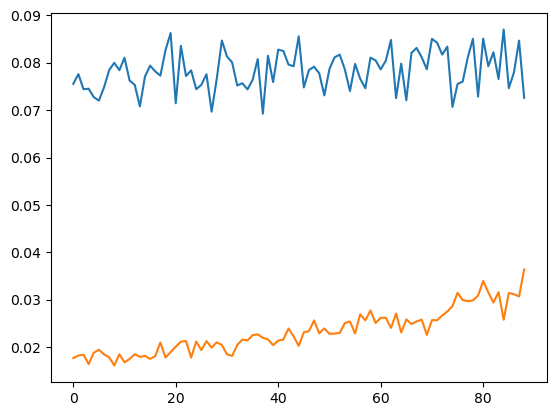

In [49]:
plt.plot(BBBIOFF)
plt.plot(BBBROFF)

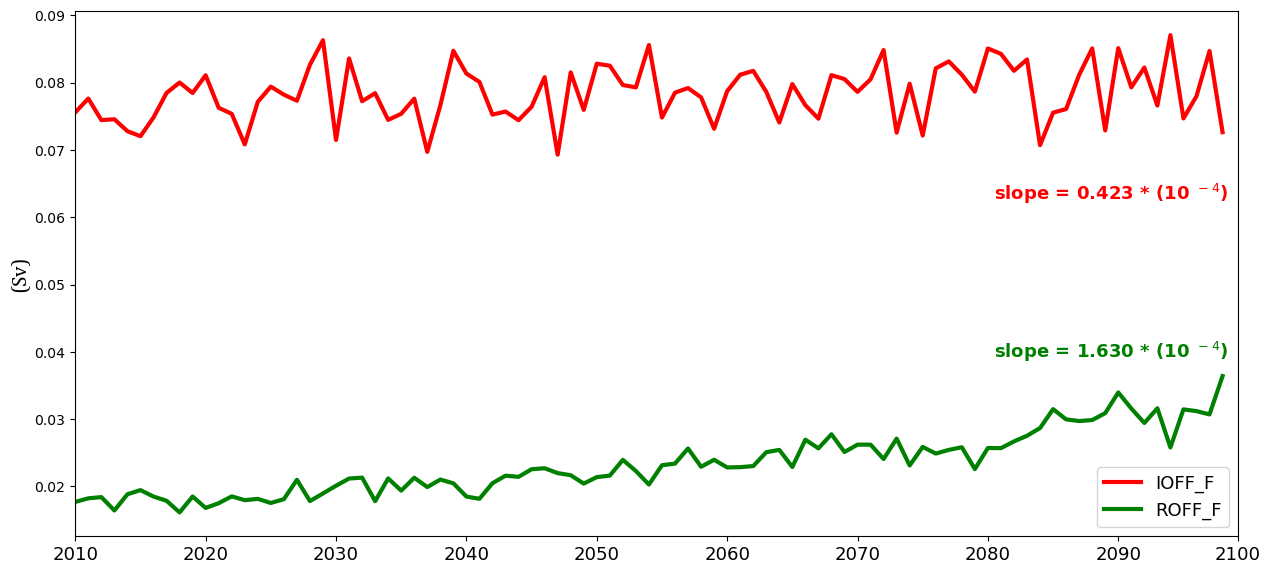

In [50]:
my_font = {'fontname':'Cambria', 'size':'15'}
fig = plt.figure(figsize=(15,15), dpi=100)
ax = plt.subplot(2, 1, 1)
#ax.plot(resultAASW_trans2,color = 'k',linestyle = '-', linewidth = 2, label = 'HR-PI')
#ax.plot(SFWFdata123*100000-QFLUXdata1234*100000,color = 'lightgrey',linestyle = '-', linewidth = 1)
ax.plot(CCC,BBBIOFF,color = 'red',linestyle = '-', linewidth = 3, label = 'IOFF_F')
ax.plot(CCC,BBBROFF,color = 'green',linestyle = '-', linewidth = 3, label = 'ROFF_F')
#ax.set_ylim((-3.5,1.5))
ax.set_xlim((0,1070))
#ax.plot([0,1100],[0,0],'grey',linewidth=2)
#ax.plot([0,1100],[-10,-10],'grey',linewidth=0.5)
ax.legend(fontsize = 13,loc='lower right') 
ax.set_ylabel('(Sv)', **my_font)
ax.set_xticks([0,120,240,360,480,600,720,840,960,1070])
ax.set_xticklabels(['2010','2020','2030','2040','2050','2060','2070','2080','2090','2100'], fontsize = 13)
#ax.set_title('Surface freshwater flux budget on Antarctic shelf (depth < 1000m)', **my_font)
#ax.text(0.02, 0.05, '(a)', transform=ax.transAxes,size=30, weight='bold')
ax.text(0.79, 0.64, 'slope = 0.423 * (10 $^-$$^4$)', transform=ax.transAxes,size=13, color = 'r',weight='bold')
ax.text(0.79, 0.34, 'slope = 1.630 * (10 $^-$$^4$)', transform=ax.transAxes,size=13, color = 'green',weight='bold')

plt.savefig("SALTIOFF.png",bbox_inches='tight')

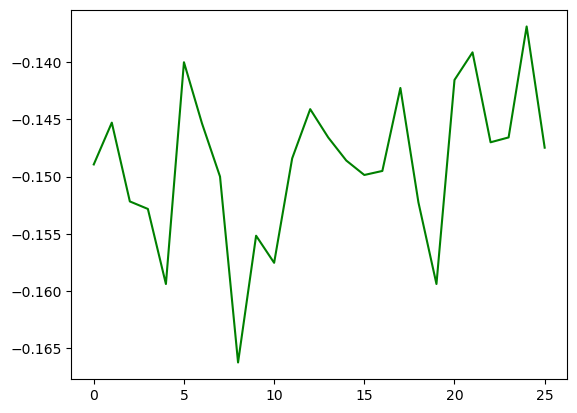

In [51]:
plt.plot(BBBICE[0:26],color = 'green')

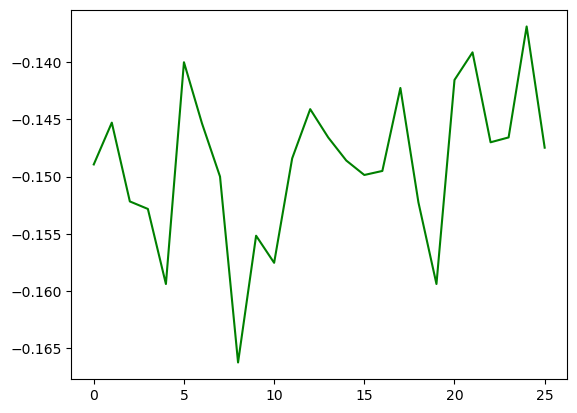

In [52]:
plt.plot(BBBICE[0:26],color = 'green')

In [53]:
BBBICE

masked_array(data=[-0.1489318289756474, -0.14527801273075733,
                   -0.15216542694650304, -0.15282337377788616,
                   -0.15938527491238702, -0.13999534243727468,
                   -0.145343330988698, -0.1499944118259291,
                   -0.1662462577013887, -0.15516410929350696,
                   -0.1575325869054661, -0.1484036028428793,
                   -0.14409748946296777, -0.14657538562831735,
                   -0.14858926705782705, -0.14985375774682722,
                   -0.14950101153384573, -0.142244132621742,
                   -0.15224851745370863, -0.15938429651069055,
                   -0.14154490713346182, -0.13913187063735769,
                   -0.14699432341824412, -0.14657002430546992,
                   -0.13686979838804764, -0.14746720811537342,
                   -0.15159913770688957, -0.15414451067410348,
                   -0.1568221270612808, -0.15379339129184383,
                   -0.157522346573321, -0.14333233982284477,
    